# Ensemble Learning with LightGBM and XGBoost

This notebook introduces ensemble learning on a real tabular classification problem.

Dataset: Forest Cover Type from `scikit-learn` when available. We predict one of seven forest cover classes from cartographic features such as elevation, slope, soil type, wilderness area, and distance to roads or water. If the dataset is not cached and cannot be downloaded, the notebook falls back to the bundled Digits dataset so the workflow still runs.

We will cover:

- why a single tree is a weak but useful building block;
- how boosting combines many trees into a stronger model;
- why Logistic Regression is a useful baseline, but can underfit nonlinear tabular patterns;
- how to train LightGBM and XGBoost through their `scikit-learn` classifier APIs;
- how to compare models with accuracy, balanced accuracy, and macro F1;
- how to combine LightGBM and XGBoost with a simple soft-voting ensemble;
- how to inspect feature importances from both libraries.

## Pinned Extra Dependencies

This notebook expects the following extra packages:

```bash
python -m pip install lightgbm==4.3.0 xgboost==2.0.3
```

The repository also includes `Topic 9. Ensembles/requirements-ensembles.txt` with those exact pins. The notebook checks the installed versions, but it does not install anything automatically.

In [1]:
import time
import warnings
from importlib.metadata import PackageNotFoundError, version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype, load_digits
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

REQUIRED_EXTRA_PACKAGES = {
    "lightgbm": "4.3.0",
    "xgboost": "2.0.3",
}


def check_extra_package(package_name, required_version):
    try:
        installed_version = version(package_name)
    except PackageNotFoundError as exc:
        raise ImportError(
            f"Install the pinned extra dependency first: "
            f"python -m pip install {package_name}=={required_version}"
        ) from exc

    if installed_version != required_version:
        warnings.warn(
            f"Expected {package_name}=={required_version}, "
            f"but found {installed_version}. Results may differ slightly.",
            stacklevel=2,
        )

    return installed_version


installed_versions = {
    package_name: check_extra_package(package_name, required_version)
    for package_name, required_version in REQUIRED_EXTRA_PACKAGES.items()
}

import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATASET_SAMPLE_SIZE = 50_000

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (9, 5),
})

installed_versions

{'lightgbm': '4.3.0', 'xgboost': '2.0.3'}

## 1. Load a Tabular Dataset

The preferred dataset is Forest Cover Type. It is useful here because it is larger than most toy datasets, multiclass, and full of nonlinear feature interactions. For example, elevation, slope, soil type, and wilderness area can interact in ways that a linear model cannot express unless we manually create many interaction features.

The first run may download the dataset through `scikit-learn`. If that fails, the notebook uses the built-in Digits dataset as a fallback.

In [2]:
def load_teaching_dataset(sample_size=DATASET_SAMPLE_SIZE):
    try:
        covtype = fetch_covtype(as_frame=True)
        frame = covtype.frame.copy()

        X_all = frame.drop(columns="Cover_Type")
        y_all = frame["Cover_Type"].astype(int) - 1

        label_names = {
            label: f"cover type {label + 1}"
            for label in sorted(y_all.unique())
        }

        dataset_info = {
            "name": "Forest Cover Type",
            "source": "sklearn.datasets.fetch_covtype",
            "note": "Target was recoded from 1..7 to 0..6 for XGBoost compatibility.",
            "fallback_used": False,
        }

    except Exception as error:
        print("Could not load Forest Cover Type. Using the bundled Digits fallback.")
        print(f"Reason: {type(error).__name__}: {error}")

        digits = load_digits(as_frame=True)
        frame = digits.frame.copy()

        X_all = frame.drop(columns="target")
        y_all = frame["target"].astype(int)

        label_names = {
            int(label): str(label)
            for label in sorted(y_all.unique())
        }

        dataset_info = {
            "name": "Digits fallback",
            "source": "sklearn.datasets.load_digits",
            "note": "Fallback dataset. The LightGBM/XGBoost lift may be smaller because this dataset is small.",
            "fallback_used": True,
        }

    if len(X_all) > sample_size:
        X_sample, _, y_sample, _ = train_test_split(
            X_all,
            y_all,
            train_size=sample_size,
            stratify=y_all,
            random_state=RANDOM_STATE,
        )
    else:
        X_sample = X_all.copy()
        y_sample = y_all.copy()

    X_sample = X_sample.reset_index(drop=True)
    y_sample = y_sample.reset_index(drop=True).astype(int)

    return X_sample, y_sample, label_names, dataset_info


X, y, label_names, dataset_info = load_teaching_dataset()
target_labels = sorted(label_names)
class_names = [label_names[label] for label in target_labels]

dataset_summary = pd.DataFrame({
    "dataset": [dataset_info["name"]],
    "source": [dataset_info["source"]],
    "rows_used": [len(X)],
    "features": [X.shape[1]],
    "classes": [len(target_labels)],
    "note": [dataset_info["note"]],
})

class_summary = (
    y.value_counts()
    .sort_index()
    .rename_axis("class_id")
    .to_frame("count")
)
class_summary["class_name"] = [label_names[label] for label in class_summary.index]
class_summary["share"] = class_summary["count"] / len(y)

display(dataset_summary)
display(class_summary)
X.head()

,dataset,source,rows_used,features,classes,note
0,Forest Cover Type,sklearn.datasets.fetch_covtype,50000,54,7,Target was recoded from 1..7 to 0..6 for XGBoo...


,count,class_name,share
class_id,,,
0,18230,cover type 1,0.3646
1,24380,cover type 2,0.4876
2,3077,cover type 3,0.0615
3,236,cover type 4,0.0047
4,817,cover type 5,0.0163
5,1495,cover type 6,0.0299
6,1765,cover type 7,0.0353


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2720.0,36.0,17.0,30.0,0.0,1308.0,217.0,201.0,114.0,2255.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2579.0,293.0,18.0,323.0,109.0,648.0,167.0,233.0,206.0,577.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3021.0,0.0,4.0,234.0,39.0,228.0,214.0,232.0,156.0,579.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2489.0,19.0,32.0,212.0,88.0,1159.0,179.0,157.0,97.0,882.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2655.0,216.0,21.0,192.0,139.0,1758.0,193.0,254.0,190.0,234.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Inspect the Learning Problem

A good baseline check is class balance. For a multiclass problem, a high raw accuracy can hide weak performance on smaller classes, so we will report macro F1 and balanced accuracy later.

The PCA plot is only a two-dimensional projection. It is not the modeling space, but it helps show that classes overlap and are not separated by one obvious straight line.

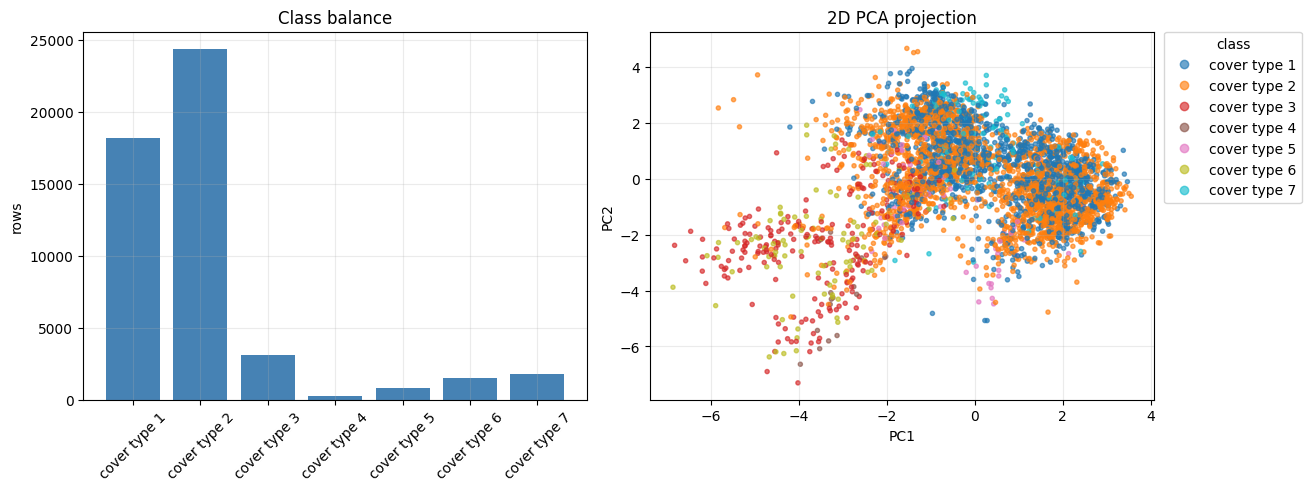

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
vis_size = min(4_000, len(X))
vis_indices = rng.choice(len(X), size=vis_size, replace=False)

X_vis_scaled = StandardScaler().fit_transform(X.iloc[vis_indices])
pca_coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_vis_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

class_counts = y.value_counts().sort_index()
axes[0].bar(
    [label_names[label] for label in class_counts.index],
    class_counts.values,
    color="steelblue",
)
axes[0].set_title("Class balance")
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", rotation=45)

scatter = axes[1].scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=y.iloc[vis_indices],
    cmap="tab10",
    s=9,
    alpha=0.65,
)
axes[1].set_title("2D PCA projection")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

handles, _ = scatter.legend_elements()
axes[1].legend(
    handles,
    class_names,
    title="class",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
)

plt.show()

## 3. Train/Test Split

We use a stratified split so every class has roughly the same share in train and test. The test set stays untouched until final evaluation.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "class_count": [y_train.nunique(), y_test.nunique()],
}, index=["train", "test"])

split_summary

,rows,class_count
train,37500,7
test,12500,7


## 4. Ensemble Intuition

A Decision Tree predicts with rules such as `feature <= threshold`. One shallow tree is easy to inspect, but it is usually too simple to solve a hard problem.

Boosting turns many shallow or medium-depth trees into one strong model. Each new tree focuses on errors the current ensemble still makes. Conceptually:

`current_model = previous_model + learning_rate * next_tree`

LightGBM and XGBoost are highly optimized implementations of gradient boosted decision trees.

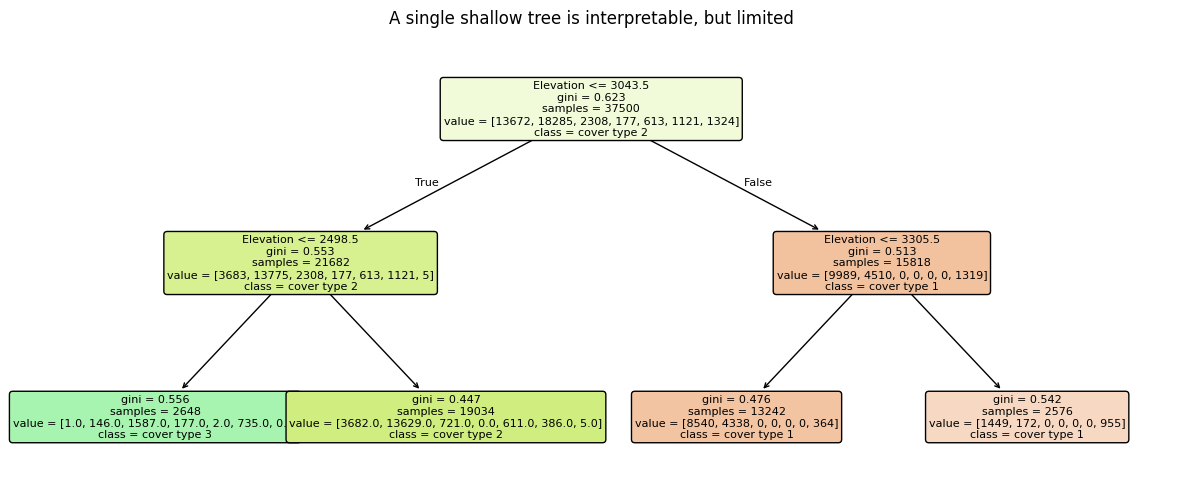

In [5]:
tiny_tree = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=max(20, len(X_train) // 200),
    random_state=RANDOM_STATE,
)
tiny_tree.fit(X_train, y_train)

plt.figure(figsize=(15, 6))
plot_tree(
    tiny_tree,
    feature_names=list(X.columns),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("A single shallow tree is interpretable, but limited")
plt.show()

## 5. Define Baseline and Ensemble Models

We compare four models:

- `DummyClassifier`: predicts the most common class;
- `LogisticRegression`: a strong linear baseline with scaling;
- `LGBMClassifier`: LightGBM through its `scikit-learn` API;
- `XGBClassifier`: XGBoost through its `scikit-learn` API.

Logistic Regression is not a weak model. It is a useful baseline because it answers a clear question: how far can a mostly linear decision function get us?

For multiclass classification, Logistic Regression learns one linear score per class and converts those scores into probabilities with the softmax function. Because the scores are linear combinations of the input features, the model cannot naturally learn rules such as "high elevation matters only for specific soil types" unless we manually add those interaction features.

In [6]:
N_ESTIMATORS = 300

models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2_000, solver="lbfgs"),
    ),
    "LightGBM": LGBMClassifier(
        objective="multiclass",
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=2,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),
}

models

{'Dummy': DummyClassifier(strategy='most_frequent'),
 'Logistic Regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression', LogisticRegression(max_iter=2000))]),
 'LightGBM': LGBMClassifier(colsample_bytree=0.9, learning_rate=0.05, min_child_samples=30,
                n_estimators=300, n_jobs=-1, objective='multiclass',
                random_state=42, reg_lambda=1.0, subsample=0.9, verbose=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=

## 6. Train and Evaluate

Accuracy is easy to read, but it can be dominated by large classes. Macro F1 gives every class equal weight, so it is a better headline metric when small classes matter.

In [7]:
def score_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }


def fit_and_evaluate(name, model, X_train, y_train, X_test, y_test):
    started_at = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started_at

    y_pred = model.predict(X_test)
    row = {
        "model": name,
        "fit_seconds": fit_seconds,
        **score_predictions(y_test, y_pred),
    }

    return model, row


trained_models = {}
rows = []

for name, model in models.items():
    print(f"Training {name}...")
    trained_model, row = fit_and_evaluate(
        name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
    )
    trained_models[name] = trained_model
    rows.append(row)

results = (
    pd.DataFrame(rows)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

logistic_macro_f1 = results.loc["Logistic Regression", "macro_f1"]
logistic_accuracy = results.loc["Logistic Regression", "accuracy"]

comparison = results.copy()
comparison["macro_f1_lift_vs_logistic"] = comparison["macro_f1"] - logistic_macro_f1
comparison["accuracy_lift_vs_logistic"] = comparison["accuracy"] - logistic_accuracy

comparison.style.format({
    "fit_seconds": "{:.2f}",
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "macro_f1": "{:.3f}",
    "weighted_f1": "{:.3f}",
    "macro_f1_lift_vs_logistic": "{:+.3f}",
    "accuracy_lift_vs_logistic": "{:+.3f}",
})

Training Dummy...
Training Logistic Regression...
Training LightGBM...
Training XGBoost...


,fit_seconds,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_f1_lift_vs_logistic,accuracy_lift_vs_logistic
model,,,,,,,
LightGBM,4.08,0.854,0.780,0.811,0.852,+0.281,+0.129
XGBoost,5.11,0.822,0.724,0.764,0.820,+0.235,+0.097
Logistic Regression,4.85,0.725,0.509,0.530,0.713,+0.000,+0.000
Dummy,0.00,0.488,0.143,0.094,0.320,-0.436,-0.237


## 7. Soft Voting: An Ensemble of Ensembles

LightGBM and XGBoost are already ensembles. We can still combine them by averaging their predicted class probabilities. This is called soft voting.

Soft voting is simple, but often competitive when the models make partially different errors.

In [8]:
lgbm_classes = trained_models["LightGBM"].classes_
xgb_classes = trained_models["XGBoost"].classes_

if not np.array_equal(lgbm_classes, xgb_classes):
    raise ValueError("LightGBM and XGBoost learned different class orders.")

soft_vote_proba = (
    trained_models["LightGBM"].predict_proba(X_test)
    + trained_models["XGBoost"].predict_proba(X_test)
) / 2
soft_vote_pred = lgbm_classes[np.argmax(soft_vote_proba, axis=1)]

soft_vote_row = {
    "model": "LightGBM + XGBoost Soft Vote",
    "fit_seconds": 0.0,
    **score_predictions(y_test, soft_vote_pred),
}

soft_vote_comparison = pd.concat([
    comparison,
    pd.DataFrame([soft_vote_row]).set_index("model"),
], axis=0)

soft_vote_comparison["macro_f1_lift_vs_logistic"] = (
    soft_vote_comparison["macro_f1"] - logistic_macro_f1
)
soft_vote_comparison["accuracy_lift_vs_logistic"] = (
    soft_vote_comparison["accuracy"] - logistic_accuracy
)

soft_vote_comparison.sort_values("macro_f1", ascending=False).style.format({
    "fit_seconds": "{:.2f}",
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "macro_f1": "{:.3f}",
    "weighted_f1": "{:.3f}",
    "macro_f1_lift_vs_logistic": "{:+.3f}",
    "accuracy_lift_vs_logistic": "{:+.3f}",
})

,fit_seconds,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_f1_lift_vs_logistic,accuracy_lift_vs_logistic
model,,,,,,,
LightGBM,4.08,0.854,0.780,0.811,0.852,+0.281,+0.129
LightGBM + XGBoost Soft Vote,0.00,0.842,0.760,0.798,0.840,+0.268,+0.117
XGBoost,5.11,0.822,0.724,0.764,0.820,+0.235,+0.097
Logistic Regression,4.85,0.725,0.509,0.530,0.713,+0.000,+0.000
Dummy,0.00,0.488,0.143,0.094,0.320,-0.436,-0.237


## 8. Per-Class Performance

The aggregate score tells us who wins overall. The classification report shows which classes are easy or difficult for each model.

In [9]:
models_for_report = {
    "Logistic Regression": trained_models["Logistic Regression"],
    "LightGBM": trained_models["LightGBM"],
    "XGBoost": trained_models["XGBoost"],
}

for name, model in models_for_report.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(
        y_test,
        model.predict(X_test),
        labels=target_labels,
        target_names=class_names,
        zero_division=0,
    ))

print("=" * 80)
print("LightGBM + XGBoost Soft Vote")
print("=" * 80)
print(classification_report(
    y_test,
    soft_vote_pred,
    labels=target_labels,
    target_names=class_names,
    zero_division=0,
))

Logistic Regression
              precision    recall  f1-score   support

cover type 1       0.71      0.70      0.70      4558
cover type 2       0.75      0.80      0.78      6095
cover type 3       0.67      0.83      0.74       769
cover type 4       0.74      0.49      0.59        59
cover type 5       0.25      0.00      0.01       204
cover type 6       0.49      0.19      0.28       374
cover type 7       0.69      0.55      0.61       441

    accuracy                           0.72     12500
   macro avg       0.61      0.51      0.53     12500
weighted avg       0.71      0.72      0.71     12500

LightGBM
              precision    recall  f1-score   support

cover type 1       0.85      0.83      0.84      4558
cover type 2       0.85      0.89      0.87      6095
cover type 3       0.86      0.88      0.87       769
cover type 4       0.87      0.80      0.83        59
cover type 5       0.90      0.50      0.65       204
cover type 6       0.77      0.70      0.73      

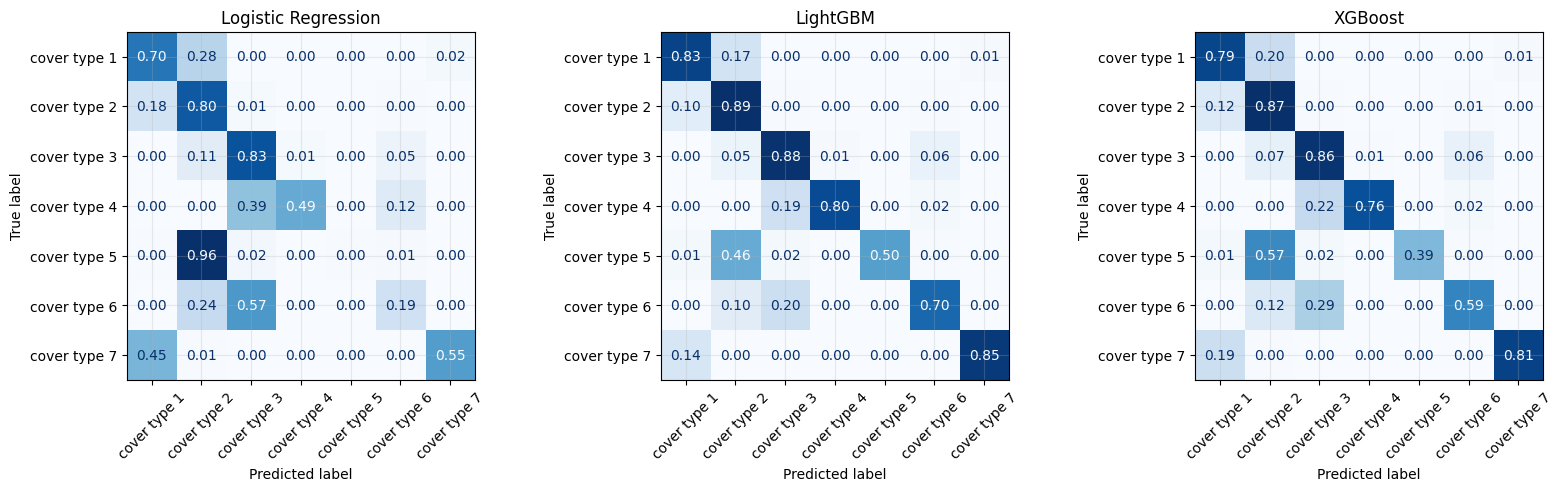

In [10]:
names_to_plot = ["Logistic Regression", "LightGBM", "XGBoost"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for ax, name in zip(axes, names_to_plot):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        trained_models[name].predict(X_test),
        labels=target_labels,
        display_labels=class_names,
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)

plt.show()

## 9. Feature Importance

Tree ensembles can rank features by how much they contribute to splits. LightGBM and XGBoost compute importance differently, so the raw scales are not directly comparable. The plot below scales each library's importance values to its own maximum.

,LightGBM_split_count,XGBoost_gain,LightGBM_rank,XGBoost_rank,average_rank
Elevation,8349,0.0872,3.0,2.0,2.5
Wilderness_Area_0,638,0.0389,11.0,6.0,8.5
Soil_Type_3,397,0.0347,13.0,8.0,10.5
Wilderness_Area_3,277,0.1011,20.0,1.0,10.5
Soil_Type_1,272,0.0486,21.0,4.0,12.5
Wilderness_Area_2,556,0.0264,12.0,13.0,12.5
Horizontal_Distance_To_Roadways,10169,0.0131,1.0,25.0,13.0
Horizontal_Distance_To_Hydrology,4731,0.0139,5.0,23.0,14.0
Horizontal_Distance_To_Fire_Points,9496,0.0121,2.0,27.0,14.5
Soil_Type_31,294,0.0296,18.0,12.0,15.0


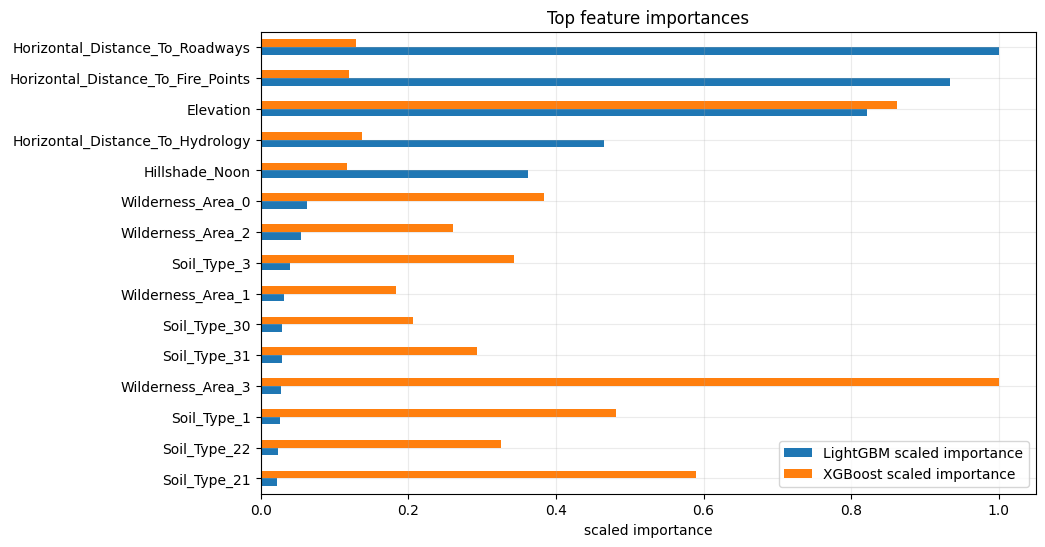

In [11]:
lgbm_importance = pd.Series(
    trained_models["LightGBM"].feature_importances_,
    index=X.columns,
    name="LightGBM_split_count",
)

xgb_importance = pd.Series(
    trained_models["XGBoost"].feature_importances_,
    index=X.columns,
    name="XGBoost_gain",
)

importance = pd.concat([lgbm_importance, xgb_importance], axis=1).fillna(0)
importance["LightGBM_rank"] = importance["LightGBM_split_count"].rank(ascending=False)
importance["XGBoost_rank"] = importance["XGBoost_gain"].rank(ascending=False)
importance["average_rank"] = importance[["LightGBM_rank", "XGBoost_rank"]].mean(axis=1)

top_importance = importance.sort_values("average_rank").head(15)

scaled_importance = top_importance[["LightGBM_split_count", "XGBoost_gain"]].copy()
scaled_importance = scaled_importance / scaled_importance.max().replace(0, np.nan)
scaled_importance = scaled_importance.rename(columns={
    "LightGBM_split_count": "LightGBM scaled importance",
    "XGBoost_gain": "XGBoost scaled importance",
})

display(top_importance)

ax = scaled_importance.sort_values("LightGBM scaled importance").plot(
    kind="barh",
    figsize=(10, 6),
)
ax.set_title("Top feature importances")
ax.set_xlabel("scaled importance")
ax.set_ylabel("")
plt.show()

## 10. What to Remember

- Logistic Regression is fast, stable, and interpretable, but its default decision boundaries are linear.
- A single tree can model nonlinear rules, but it is often unstable or too simple when restricted.
- Boosted trees build a strong predictor by adding many trees sequentially.
- LightGBM and XGBoost are strong default choices for structured tabular data because they capture thresholds, feature interactions, and nonlinear effects without manual feature engineering.
- Macro F1 and balanced accuracy are useful when class sizes differ, because they make minority-class performance visible.
- Soft voting can improve results when strong models make different mistakes, but it is not guaranteed to beat the best individual model.